<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
#!pip install pandas 
#!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
#!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey_data.csv")

# Display the first few rows of the data to understand its structure
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


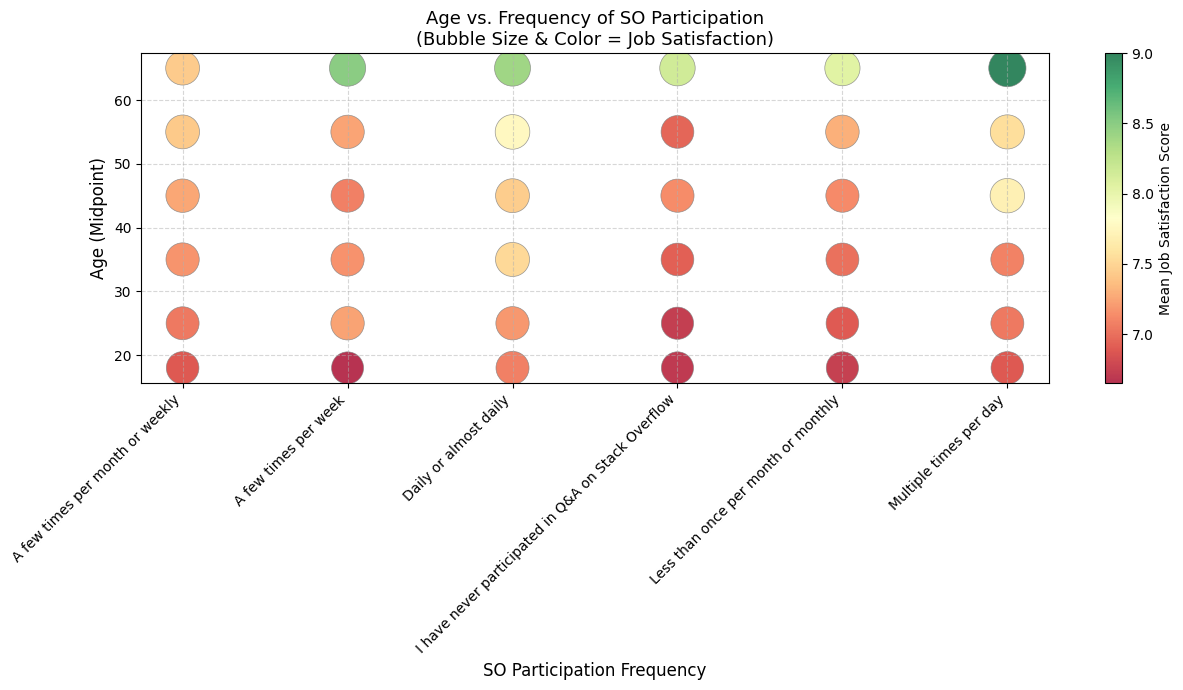

In [5]:
# Task 1.1: Bubble Plot for Age vs. Frequency of Participation
plot_df = df[['Age', 'SOPartFreq', 'JobSat']].dropna().copy()

# Extract first number from age strings, non-numeric values become NaN
plot_df['Age_numeric'] = pd.to_numeric(
    plot_df['Age'].str.replace(' years old', '').str.replace(' years or older', '').str.split('-').str[0],
    errors='coerce'
)
plot_df = plot_df.dropna(subset=['Age_numeric'])

# Aggregate: mean JobSat and count per (Age group, SOPartFreq)
agg = plot_df.groupby(['Age', 'SOPartFreq']).agg(
    Age_numeric=('Age_numeric', 'mean'),
    JobSat_mean=('JobSat', 'mean'),
    Count=('JobSat', 'count')
).reset_index()

plt.figure(figsize=(13, 7))
sc = plt.scatter(agg['SOPartFreq'], agg['Age_numeric'],
                 s=agg['JobSat_mean'] * 80,
                 c=agg['JobSat_mean'], cmap='RdYlGn',
                 alpha=0.8, edgecolors='grey', linewidth=0.5)
plt.colorbar(sc, label='Mean Job Satisfaction Score')
plt.title('Age vs. Frequency of SO Participation\n(Bubble Size & Color = Job Satisfaction)', fontsize=13)
plt.xlabel('SO Participation Frequency', fontsize=12)
plt.ylabel('Age (Midpoint)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


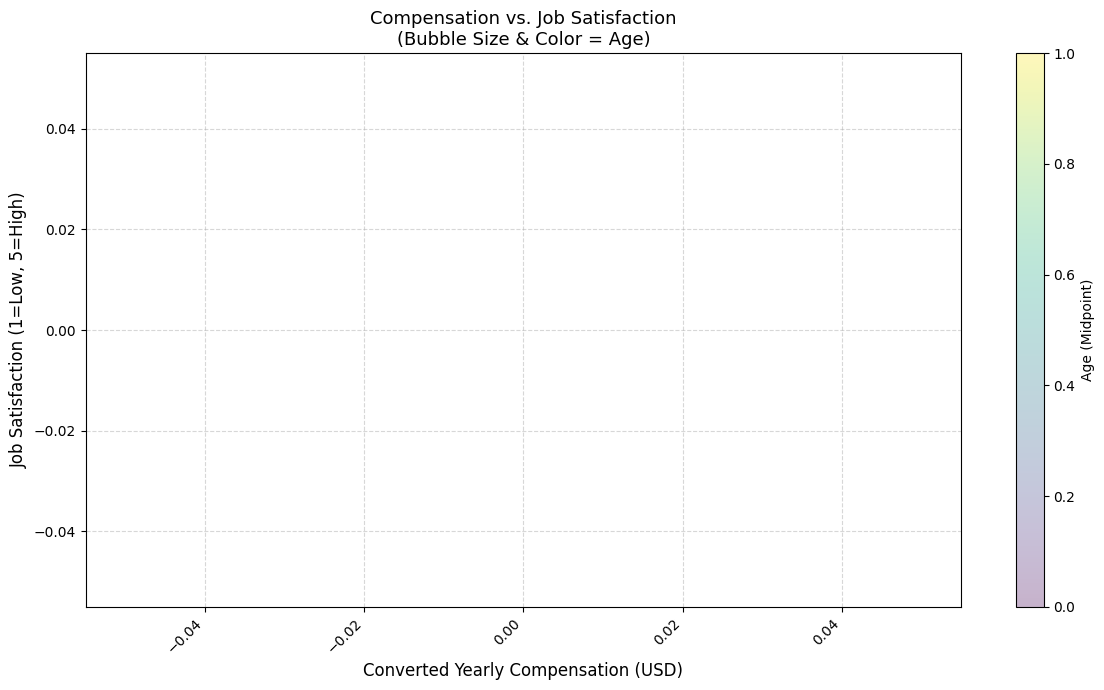

In [6]:
# Task 1.2: Bubble Plot for Compensation vs. Job Satisfaction (bubble size = Age)
import re

def age_midpoint(age_str):
    numbers = re.findall(r'\d+', str(age_str))
    if len(numbers) >= 2:
        return (int(numbers[0]) + int(numbers[1])) / 2
    elif len(numbers) == 1:
        return int(numbers[0])
    return None

jobsat_map = {
    'Very satisfied': 5, 'Slightly satisfied': 4,
    'Neither satisfied nor dissatisfied': 3,
    'Slightly dissatisfied': 2, 'Very dissatisfied': 1
}

plot_df = df[['ConvertedCompYearly', 'JobSat', 'Age']].dropna().copy()
cap = plot_df['ConvertedCompYearly'].quantile(0.99)
plot_df = plot_df[plot_df['ConvertedCompYearly'] <= cap]
plot_df['JobSat_numeric'] = plot_df['JobSat'].map(jobsat_map)
plot_df['Age_numeric'] = plot_df['Age'].apply(age_midpoint)
plot_df = plot_df.dropna()

bubble_size = (plot_df['Age_numeric'] - plot_df['Age_numeric'].min()) /               (plot_df['Age_numeric'].max() - plot_df['Age_numeric'].min()) * 200 + 20

plt.figure(figsize=(12, 7))
sc = plt.scatter(plot_df['ConvertedCompYearly'], plot_df['JobSat_numeric'],
                 s=bubble_size, alpha=0.3, c=plot_df['Age_numeric'],
                 cmap='viridis', edgecolors='none')
plt.colorbar(sc, label='Age (Midpoint)')
plt.title('Compensation vs. Job Satisfaction\n(Bubble Size & Color = Age)', fontsize=13)
plt.xlabel('Converted Yearly Compensation (USD)', fontsize=12)
plt.ylabel('Job Satisfaction (1=Low, 5=High)', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



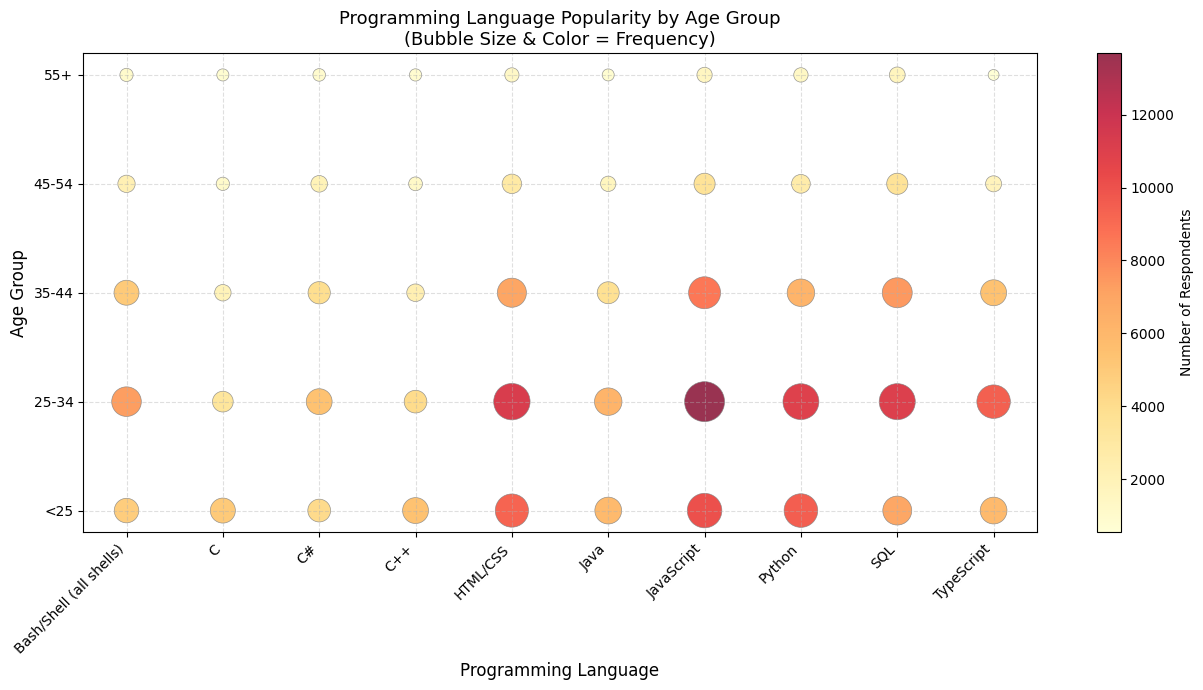

In [7]:
# Task 2.1: Bubble Plot of Technology Preferences (Languages) by Age Group
import re

def age_midpoint(age_str):
    numbers = re.findall(r'\d+', str(age_str))
    if len(numbers) >= 2:
        return (int(numbers[0]) + int(numbers[1])) / 2
    elif len(numbers) == 1:
        return int(numbers[0])
    return None

plot_df = df[['LanguageHaveWorkedWith', 'Age']].dropna().copy()
plot_df['Age_numeric'] = plot_df['Age'].apply(age_midpoint)
plot_df = plot_df.dropna(subset=['Age_numeric'])

# Explode languages and create age buckets
lang_df = plot_df.assign(Language=plot_df['LanguageHaveWorkedWith'].str.split(';')).explode('Language')
lang_df['Language'] = lang_df['Language'].str.strip()
lang_df['AgeGroup'] = pd.cut(lang_df['Age_numeric'], bins=[0,25,35,45,55,100],
                              labels=['<25','25-34','35-44','45-54','55+'])

top_langs = lang_df['Language'].value_counts().head(10).index
lang_df = lang_df[lang_df['Language'].isin(top_langs)]

agg = lang_df.groupby(['Language','AgeGroup']).size().reset_index(name='Count')

plt.figure(figsize=(13, 7))
sc = plt.scatter(agg['Language'], agg['AgeGroup'],
                 s=agg['Count'] / agg['Count'].max() * 800 + 30,
                 c=agg['Count'], cmap='YlOrRd',
                 alpha=0.8, edgecolors='grey', linewidth=0.5)
plt.colorbar(sc, label='Number of Respondents')
plt.title('Programming Language Popularity by Age Group\n(Bubble Size & Color = Frequency)', fontsize=13)
plt.xlabel('Programming Language', fontsize=12)
plt.ylabel('Age Group', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


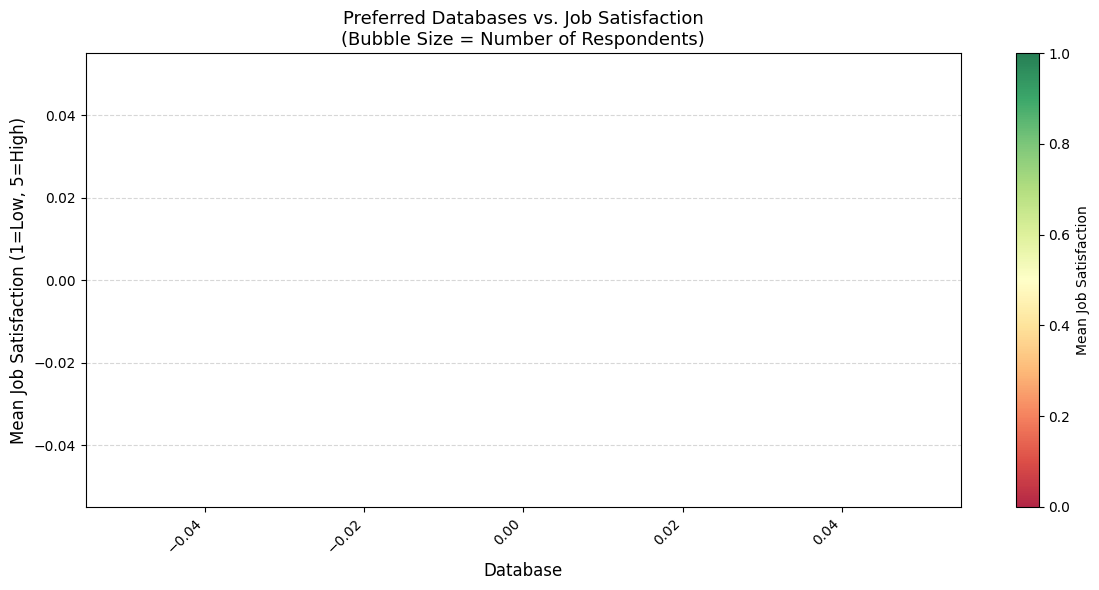

In [8]:
# Task 2.2: Bubble Plot for Preferred Databases vs. Job Satisfaction
jobsat_map = {
    'Very satisfied': 5, 'Slightly satisfied': 4,
    'Neither satisfied nor dissatisfied': 3,
    'Slightly dissatisfied': 2, 'Very dissatisfied': 1
}

plot_df = df[['DatabaseWantToWorkWith', 'JobSat']].dropna().copy()
plot_df['JobSat_numeric'] = plot_df['JobSat'].map(jobsat_map)
plot_df = plot_df.dropna()

db_df = plot_df.assign(Database=plot_df['DatabaseWantToWorkWith'].str.split(';')).explode('Database')
db_df['Database'] = db_df['Database'].str.strip()

top_dbs = db_df['Database'].value_counts().head(10).index
db_df = db_df[db_df['Database'].isin(top_dbs)]

agg = db_df.groupby('Database').agg(
    MeanSat=('JobSat_numeric', 'mean'),
    Count=('JobSat_numeric', 'count')
).reset_index().sort_values('MeanSat', ascending=False)

plt.figure(figsize=(12, 6))
sc = plt.scatter(agg['Database'], agg['MeanSat'],
                 s=agg['Count'] / agg['Count'].max() * 1000 + 50,
                 c=agg['MeanSat'], cmap='RdYlGn',
                 alpha=0.85, edgecolors='grey', linewidth=0.5)
plt.colorbar(sc, label='Mean Job Satisfaction')
plt.title('Preferred Databases vs. Job Satisfaction\n(Bubble Size = Number of Respondents)', fontsize=13)
plt.xlabel('Database', fontsize=12)
plt.ylabel('Mean Job Satisfaction (1=Low, 5=High)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


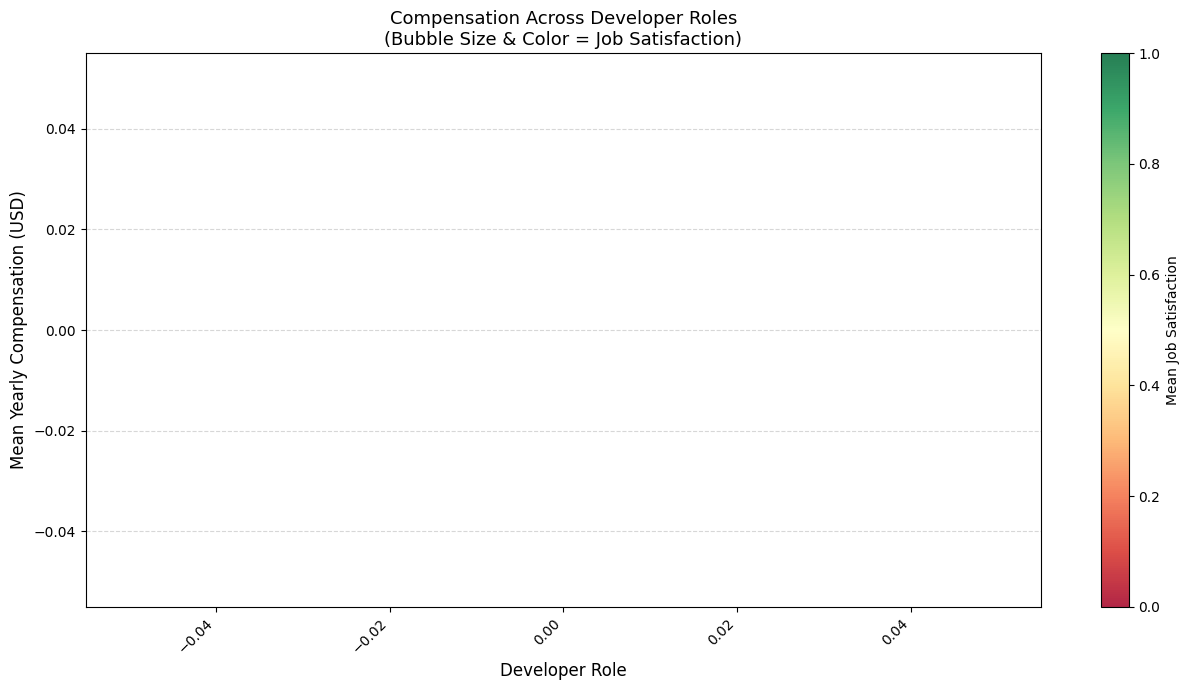

In [9]:
# Task 3.1: Bubble Plot for Compensation Across Developer Roles
jobsat_map = {
    'Very satisfied': 5, 'Slightly satisfied': 4,
    'Neither satisfied nor dissatisfied': 3,
    'Slightly dissatisfied': 2, 'Very dissatisfied': 1
}

plot_df = df[['DevType', 'ConvertedCompYearly', 'JobSat']].dropna().copy()
cap = plot_df['ConvertedCompYearly'].quantile(0.99)
plot_df = plot_df[plot_df['ConvertedCompYearly'] <= cap]
plot_df['JobSat_numeric'] = plot_df['JobSat'].map(jobsat_map)
plot_df = plot_df.dropna()

dev_df = plot_df.assign(Role=plot_df['DevType'].str.split(';')).explode('Role')
dev_df['Role'] = dev_df['Role'].str.strip()

top_roles = dev_df['Role'].value_counts().head(10).index
dev_df = dev_df[dev_df['Role'].isin(top_roles)]

agg = dev_df.groupby('Role').agg(
    MeanComp=('ConvertedCompYearly', 'mean'),
    MeanSat=('JobSat_numeric', 'mean'),
    Count=('JobSat_numeric', 'count')
).reset_index().sort_values('MeanComp', ascending=False)

plt.figure(figsize=(13, 7))
sc = plt.scatter(agg['Role'], agg['MeanComp'],
                 s=agg['MeanSat'] * 100,
                 c=agg['MeanSat'], cmap='RdYlGn',
                 alpha=0.85, edgecolors='grey', linewidth=0.5)
plt.colorbar(sc, label='Mean Job Satisfaction')
plt.title('Compensation Across Developer Roles\n(Bubble Size & Color = Job Satisfaction)', fontsize=13)
plt.xlabel('Developer Role', fontsize=12)
plt.ylabel('Mean Yearly Compensation (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


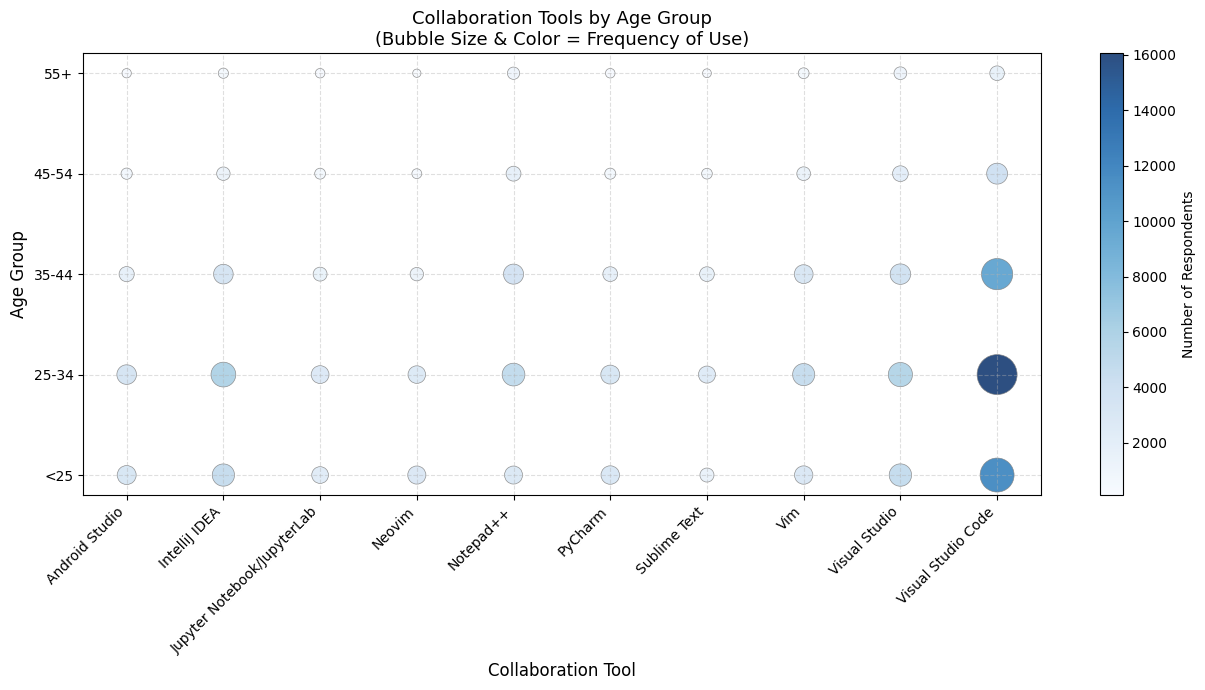

In [10]:
# Task 3.2: Bubble Plot for Collaboration Tools by Age Group
import re

def age_midpoint(age_str):
    numbers = re.findall(r'\d+', str(age_str))
    if len(numbers) >= 2:
        return (int(numbers[0]) + int(numbers[1])) / 2
    elif len(numbers) == 1:
        return int(numbers[0])
    return None

plot_df = df[['NEWCollabToolsHaveWorkedWith', 'Age']].dropna().copy()
plot_df['Age_numeric'] = plot_df['Age'].apply(age_midpoint)
plot_df = plot_df.dropna(subset=['Age_numeric'])

tool_df = plot_df.assign(Tool=plot_df['NEWCollabToolsHaveWorkedWith'].str.split(';')).explode('Tool')
tool_df['Tool'] = tool_df['Tool'].str.strip()
tool_df['AgeGroup'] = pd.cut(tool_df['Age_numeric'], bins=[0,25,35,45,55,100],
                              labels=['<25','25-34','35-44','45-54','55+'])

top_tools = tool_df['Tool'].value_counts().head(10).index
tool_df = tool_df[tool_df['Tool'].isin(top_tools)]

agg = tool_df.groupby(['Tool','AgeGroup']).size().reset_index(name='Count')

plt.figure(figsize=(13, 7))
sc = plt.scatter(agg['Tool'], agg['AgeGroup'],
                 s=agg['Count'] / agg['Count'].max() * 800 + 30,
                 c=agg['Count'], cmap='Blues',
                 alpha=0.85, edgecolors='grey', linewidth=0.5)
plt.colorbar(sc, label='Number of Respondents')
plt.title('Collaboration Tools by Age Group\n(Bubble Size & Color = Frequency of Use)', fontsize=13)
plt.xlabel('Collaboration Tool', fontsize=12)
plt.ylabel('Age Group', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



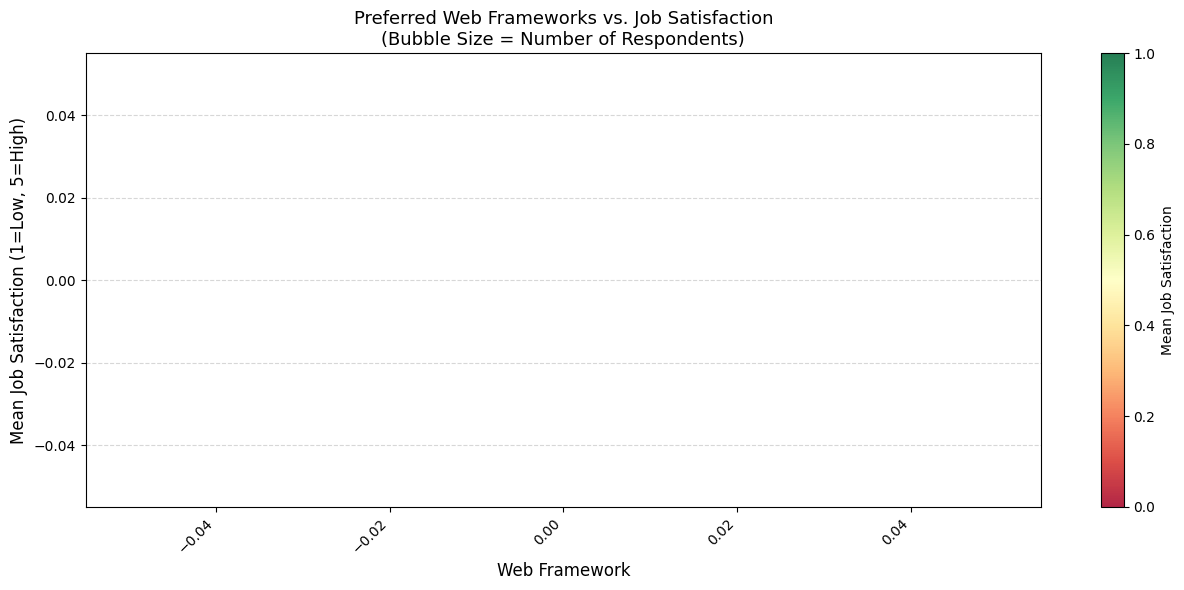

In [11]:
# Task 4.1: Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction
jobsat_map = {
    'Very satisfied': 5, 'Slightly satisfied': 4,
    'Neither satisfied nor dissatisfied': 3,
    'Slightly dissatisfied': 2, 'Very dissatisfied': 1
}

plot_df = df[['WebframeWantToWorkWith', 'JobSat']].dropna().copy()
plot_df['JobSat_numeric'] = plot_df['JobSat'].map(jobsat_map)
plot_df = plot_df.dropna()

fw_df = plot_df.assign(Framework=plot_df['WebframeWantToWorkWith'].str.split(';')).explode('Framework')
fw_df['Framework'] = fw_df['Framework'].str.strip()

top_fw = fw_df['Framework'].value_counts().head(12).index
fw_df = fw_df[fw_df['Framework'].isin(top_fw)]

agg = fw_df.groupby('Framework').agg(
    MeanSat=('JobSat_numeric', 'mean'),
    Count=('JobSat_numeric', 'count')
).reset_index().sort_values('MeanSat', ascending=False)

plt.figure(figsize=(13, 6))
sc = plt.scatter(agg['Framework'], agg['MeanSat'],
                 s=agg['Count'] / agg['Count'].max() * 1000 + 50,
                 c=agg['MeanSat'], cmap='RdYlGn',
                 alpha=0.85, edgecolors='grey', linewidth=0.5)
plt.colorbar(sc, label='Mean Job Satisfaction')
plt.title('Preferred Web Frameworks vs. Job Satisfaction\n(Bubble Size = Number of Respondents)', fontsize=13)
plt.xlabel('Web Framework', fontsize=12)
plt.ylabel('Mean Job Satisfaction (1=Low, 5=High)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



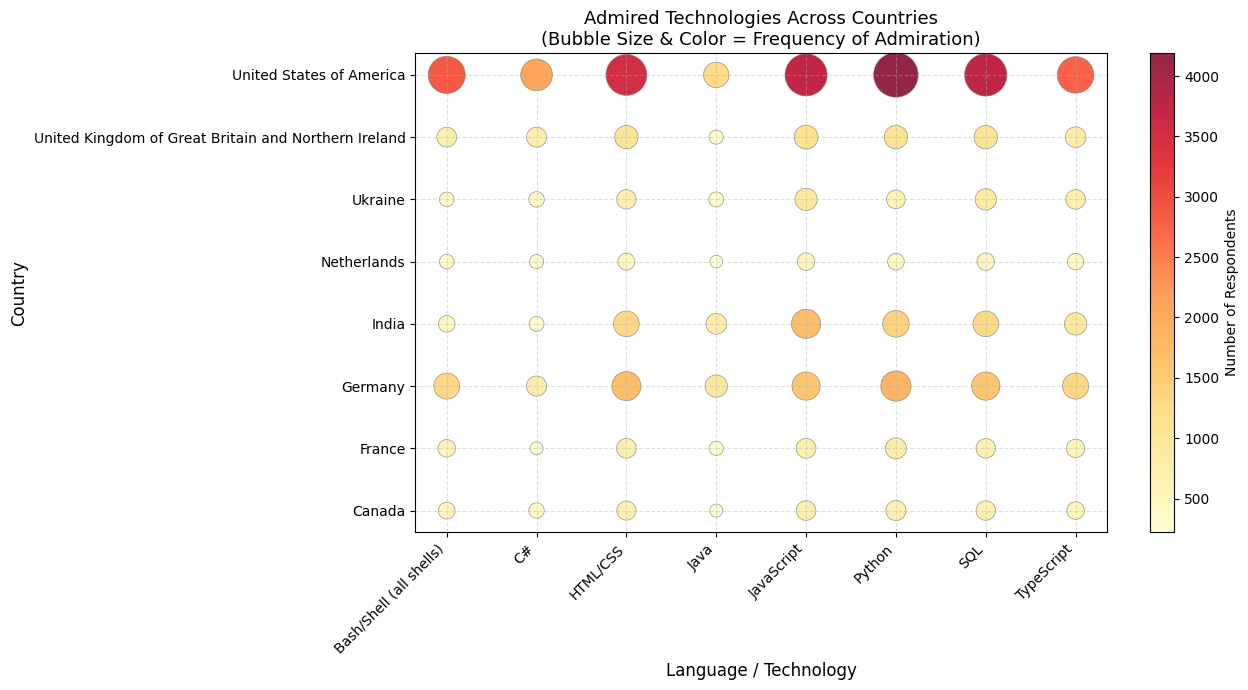

In [12]:
# Task 4.2: Bubble Plot for Admired Technologies Across Countries
plot_df = df[['LanguageAdmired', 'Country']].dropna().copy()

lang_df = plot_df.assign(Language=plot_df['LanguageAdmired'].str.split(';')).explode('Language')
lang_df['Language'] = lang_df['Language'].str.strip()

top_langs = lang_df['Language'].value_counts().head(8).index
top_countries = lang_df['Country'].value_counts().head(8).index

lang_df = lang_df[lang_df['Language'].isin(top_langs) & lang_df['Country'].isin(top_countries)]

agg = lang_df.groupby(['Language', 'Country']).size().reset_index(name='Count')

plt.figure(figsize=(13, 7))
sc = plt.scatter(agg['Language'], agg['Country'],
                 s=agg['Count'] / agg['Count'].max() * 1000 + 30,
                 c=agg['Count'], cmap='YlOrRd',
                 alpha=0.85, edgecolors='grey', linewidth=0.5)
plt.colorbar(sc, label='Number of Respondents')
plt.title('Admired Technologies Across Countries\n(Bubble Size & Color = Frequency of Admiration)', fontsize=13)
plt.xlabel('Language / Technology', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
